In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# EV PRICE PREDICTION - CAMBODIA MARKET
## Facebook Prophet with Logistic Growth + Cross-Validation
### Predicting 5 car models over 5 years with full error metrics

## 1. Data Loading & Preprocessing

In [2]:
df1 = pd.read_csv("Cambodia EV - Real Historical.csv")
df2 = pd.read_csv("Cambodia EV - Synthetic Records (New Formula).csv")
print(f"Historical: {df1.shape}, Synthetic: {df2.shape}")

Historical: (1182, 19), Synthetic: (5000, 16)


In [3]:
def preprocess_data(df):
    df_proc = df.copy()
    def parse_date(val):
        if pd.isna(val): return pd.NaT
        for fmt in ['%d-%m-%Y', '%m/%d/%Y', '%Y-%m-%d']:
            try: return pd.to_datetime(str(val).strip(), format=fmt)
            except: continue
        return pd.NaT
    df_proc['Date Listed'] = df_proc['Date Listed'].apply(parse_date)
    numeric_cols = ['Price (USD)', 'Mileage (km)', 'Power (kW)', '0-100 km/h (s)', 'Battery (kWh)', 'Range (km)']
    for col in numeric_cols:
        if col in df_proc.columns:
            df_proc[col] = pd.to_numeric(df_proc[col], errors='coerce')
    df_proc = df_proc[df_proc['Price (USD)'].notna() & (df_proc['Price (USD)'] > 0)]
    df_proc = df_proc[df_proc['Date Listed'].notna()]
    df_proc['Year'] = pd.to_numeric(df_proc['Year'], errors='coerce')
    df_proc = df_proc[(df_proc['Year'] >= 2020) & (df_proc['Year'] <= 2026)]
    df_proc = df_proc[(df_proc['Mileage (km)'].notna()) & (df_proc['Mileage (km)'] >= 0)]
    df_proc['ds'] = df_proc['Date Listed']
    def parse_batt(v):
        if pd.isna(v): return np.nan
        try:
            if '/' in str(v): return max(float(s) for s in str(v).split('/'))
            return float(v)
        except: return np.nan
    def parse_rng(v):
        if pd.isna(v): return np.nan
        try:
            if '-' in str(v): return max(float(s) for s in str(v).split('-'))
            return float(v)
        except: return np.nan
    df_proc['battery_kwh'] = df_proc['Battery (kWh)'].apply(parse_batt)
    df_proc['range_km'] = df_proc['Range (km)'].apply(parse_rng)
    df_proc['vehicle_age'] = (df_proc['ds'].dt.year - df_proc['Year']).clip(lower=0)
    cond_map = {'New': 5, 'Like New': 4, 'Excellent': 3, 'Good': 2, 'Fair': 1}
    df_proc['condition'] = df_proc['Condition'].map(cond_map).fillna(3)
    df_proc['Brand'] = df_proc['Brand'].fillna('Other')
    brand_avg = df_proc.groupby('Brand')['Price (USD)'].mean()
    df_proc['brand_premium'] = (df_proc['Brand'].map(brand_avg) >= brand_avg.quantile(0.75)).astype(int)
    df_proc['price_per_km'] = np.where(df_proc['Mileage (km)'] > 0, df_proc['Price (USD)'] / df_proc['Mileage (km)'], 0)
    df_proc = df_proc.sort_values('Date Listed').reset_index(drop=True)
    return df_proc

In [4]:
df1_proc = preprocess_data(df1)
df2_proc = preprocess_data(df2)
print(f"Processed - Historical: {df1_proc.shape}, Synthetic: {df2_proc.shape}")

Processed - Historical: (1179, 26), Synthetic: (5000, 23)


## 2. Cambodia Holidays

In [5]:
def get_cambodia_holidays():
    holidays = []
    for year in range(2020, 2031):
        holidays.append({'holiday': 'khmer_new_year', 'ds': pd.Timestamp(f'{year}-04-14'), 'lower_window': -3, 'upper_window': 7})
        holidays.append({'holiday': 'victory_day', 'ds': pd.Timestamp(f'{year}-01-07'), 'lower_window': 0, 'upper_window': 1})
        holidays.append({'holiday': 'meak_bochea', 'ds': pd.Timestamp(f'{year}-01-21'), 'lower_window': 0, 'upper_window': 1})
        holidays.append({'holiday': 'king_coronation', 'ds': pd.Timestamp(f'{year}-10-29'), 'lower_window': 0, 'upper_window': 1})
        holidays.append({'holiday': 'water_festival', 'ds': pd.Timestamp(f'{year}-11-07'), 'lower_window': -3, 'upper_window': 3})
    return pd.DataFrame(holidays)
cambodia_holidays = get_cambodia_holidays()

## 3. Build Prophet Models

In [6]:
from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

In [7]:
base_regressors = ['Mileage (km)', 'vehicle_age', 'battery_kwh', 'range_km', 'Power (kW)', '0-100 km/h (s)', 'condition', 'brand_premium', 'price_per_km']

def prepare_prophet_df(df, regressors):
    valid_reg = [r for r in regressors if r in df.columns]
    pdf = df[['ds', 'Price (USD)'] + valid_reg].copy().rename(columns={'Price (USD)': 'y'}).dropna()
    q99 = pdf['y'].quantile(0.99)
    q01 = pdf['y'].quantile(0.01)
    pdf['y'] = pdf['y'].clip(q01, q99)
    pdf['cap'] = pdf['y'].max() * 1.5
    pdf['floor'] = pdf['y'].min() * 0.5
    return pdf, valid_reg

def build_model(df, cps, sps, seasonality='additive'):
    pdf, valid_reg = prepare_prophet_df(df, base_regressors)
    split_date = pd.Timestamp('2025-06-01')
    train = pdf[pdf['ds'] < split_date].copy()
    test = pdf[pdf['ds'] >= split_date].copy()
    if len(train) < 10 or len(test) < 5:
        np.random.seed(42); idx = pdf.index.tolist(); np.random.shuffle(idx)
        s = int(len(idx)*0.8); train = pdf.loc[idx[:s]].copy(); test = pdf.loc[idx[s:]].copy()
        train['cap'] = train['y'].max()*1.5; train['floor'] = train['y'].min()*0.5
        test['cap'] = train['y'].max()*1.5; test['floor'] = train['y'].min()*0.5
    changepoints = ['2023-01-01', '2024-01-01', '2025-01-01']
    m = Prophet(growth='logistic', changepoint_prior_scale=cps, seasonality_prior_scale=sps,
                seasonality_mode=seasonality, yearly_seasonality=True, weekly_seasonality=False,
                daily_seasonality=False, changepoint_range=0.9, changepoints=changepoints,
                holidays=cambodia_holidays)
    for r in valid_reg:
        m.add_regressor(r, mode='additive')
    m.fit(train)
    return m, train, test, valid_reg

In [8]:
print("Building Historical Model...")
m1, train1, test1, reg1 = build_model(df1_proc, cps=0.01, sps=0.01, seasonality='additive')
print("Building Synthetic Model...")
m2, train2, test2, reg2 = build_model(df2_proc, cps=0.05, sps=0.1, seasonality='multiplicative')

Building Historical Model...


10:07:01 - cmdstanpy - INFO - Chain [1] start processing
10:07:02 - cmdstanpy - INFO - Chain [1] done processing
10:07:02 - cmdstanpy - INFO - Chain [1] start processing


Building Synthetic Model...


10:07:03 - cmdstanpy - INFO - Chain [1] done processing


## 4. Model Evaluation Metrics (Test Set)

In [9]:
def evaluate_model(model, test_df, name):
    pred = model.predict(test_df)
    y_true, y_pred = test_df['y'].values, pred['yhat'].values
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"{'='*50}")
    print(f"{name} MODEL - TEST SET METRICS")
    print(f"{'='*50}")
    print(f"  MAE : ${mae:,.2f}")
    print(f"  MSE : ${mse:,.2f}")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R2  : {r2:.4f}")
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

met1 = evaluate_model(m1, test1, 'Historical')
met2 = evaluate_model(m2, test2, 'Synthetic')

Historical MODEL - TEST SET METRICS
  MAE : $6,881.63
  MSE : $62,248,120.43
  RMSE: $7,889.75
  MAPE: 16.05%
  R2  : 0.7232
Synthetic MODEL - TEST SET METRICS
  MAE : $6,672.12
  MSE : $77,507,086.18
  RMSE: $8,803.81
  MAPE: 15.94%
  R2  : 0.7941


In [10]:
metrics_df = pd.DataFrame({
    'Metric': ['MAE ($)', 'MSE ($)', 'RMSE ($)', 'MAPE (%)', 'R2'],
    'Historical': [f"${met1['MAE']:,.0f}", f"${met1['MSE']:,.0f}", f"${met1['RMSE']:,.0f}", f"{met1['MAPE']:.2f}%", f"{met1['R2']:.4f}"],
    'Synthetic': [f"${met2['MAE']:,.0f}", f"${met2['MSE']:,.0f}", f"${met2['RMSE']:,.0f}", f"{met2['MAPE']:.2f}%", f"{met2['R2']:.4f}"]
})
print("MODEL PERFORMANCE COMPARISON")
display(metrics_df)

MODEL PERFORMANCE COMPARISON


,Metric,Historical,Synthetic
0,MAE ($),"$6,882","$6,672"
1,MSE ($),"$62,248,120","$77,507,086"
2,RMSE ($),"$7,890","$8,804"
3,MAPE (%),16.05%,15.94%
4,R2,0.7232,0.7941


## 5. Cross-Validation

In [11]:
from prophet.diagnostics import cross_validation, performance_metrics

def run_cv(model, train, name, horizon='60 days', initial='400 days', period='30 days'):
    try:
        df_cv = cross_validation(model, initial=initial, period=period, horizon=horizon)
        df_pm = performance_metrics(df_cv)
        print(f"\n--- {name} CV ---")
        print(f"  MAE: ${df_pm['mae'].mean():,.0f}")
        print(f"  RMSE: ${df_pm['rmse'].mean():,.0f}")
        print(f"  MAPE: {df_pm['mape'].mean()*100:.2f}%")
        print(f"  Coverage: {df_pm['coverage'].mean()*100:.1f}%")
        return df_cv, df_pm
    except Exception as e:
        print(f"CV failed for {name}: {str(e)[:80]}")
        return None, None

cv1, pm1 = run_cv(m1, train1, 'Historical')
cv2, pm2 = run_cv(m2, train2, 'Synthetic', period='60 days')

  0%|          | 0/50 [00:00<?, ?it/s]

10:07:04 - cmdstanpy - INFO - Chain [1] start processing
10:07:05 - cmdstanpy - INFO - Chain [1] done processing
10:07:05 - cmdstanpy - INFO - Chain [1] start processing
10:07:05 - cmdstanpy - INFO - Chain [1] done processing
10:07:05 - cmdstanpy - INFO - Chain [1] start processing
10:07:05 - cmdstanpy - INFO - Chain [1] done processing
10:07:06 - cmdstanpy - INFO - Chain [1] start processing
10:07:06 - cmdstanpy - INFO - Chain [1] done processing
10:07:06 - cmdstanpy - INFO - Chain [1] start processing
10:07:06 - cmdstanpy - INFO - Chain [1] done processing
10:07:07 - cmdstanpy - INFO - Chain [1] start processing
10:07:07 - cmdstanpy - INFO - Chain [1] done processing
10:07:07 - cmdstanpy - INFO - Chain [1] start processing
10:07:07 - cmdstanpy - INFO - Chain [1] done processing
10:07:07 - cmdstanpy - INFO - Chain [1] start processing
10:07:07 - cmdstanpy - INFO - Chain [1] done processing
10:07:08 - cmdstanpy - INFO - Chain [1] start processing
10:07:08 - cmdstanpy - INFO - Chain [1]


--- Historical CV ---
  MAE: $9,177
  RMSE: $15,645
  MAPE: 21.31%
  Coverage: 61.1%


  0%|          | 0/23 [00:00<?, ?it/s]

10:07:58 - cmdstanpy - INFO - Chain [1] start processing
10:07:59 - cmdstanpy - INFO - Chain [1] done processing
10:07:59 - cmdstanpy - INFO - Chain [1] start processing
10:08:00 - cmdstanpy - INFO - Chain [1] done processing
10:08:04 - cmdstanpy - INFO - Chain [1] start processing
10:08:05 - cmdstanpy - INFO - Chain [1] done processing


CV failed for Synthetic: Maximum allowed size exceeded


## 6. Predicting 5 Car Models (5-Year Forecast)

In [12]:
# Select top 5 popular EV models in Cambodia
target_models = [
    ('Tesla', 'Tesla Model 3'),
    ('MG', 'MG ZS EV'),
    ('BYD', 'BYD Atto 3'),
    ('AION', 'AION ES'),
    ('Nissan', 'Nissan Leaf'),
]

def get_model_avg_features(df, brand, model_name):
    subset = df[(df['Brand'] == brand) & (df['Model Name'] == model_name)]
    if len(subset) == 0:
        return None
    av = subset.mean(numeric_only=True)
    return {
        'price': av['Price (USD)'],
        'mileage': av['Mileage (km)'],
        'battery': av.get('battery_kwh', np.nan),
        'range_km': av.get('range_km', np.nan),
        'power': av.get('Power (kW)', np.nan),
        'accel': av.get('0-100 km/h (s)', np.nan),
        'condition': av.get('condition', 3),
        'brand_premium': av.get('brand_premium', 0),
    }

car_data = {}
for brand, model in target_models:
    feat = get_model_avg_features(df1_proc, brand, model)
    if feat:
        car_data[f'{brand} {model}'] = feat
        print(f"{brand} {model}: ${feat['price']:,.0f}, {feat['mileage']:.0f}km, {feat['battery']:.1f}kWh")
    else:
        print(f"WARNING: {brand} {model} not found!")

Tesla Tesla Model 3: $44,041, 29563km, nankWh
MG MG ZS EV: $29,191, 26989km, nankWh
BYD BYD Atto 3: $27,902, 25016km, nankWh
AION AION ES: $28,084, 13012km, 55.6kWh
Nissan Nissan Leaf: $29,654, 28872km, nankWh


In [13]:
# Fill NaN regressor values with training medians before predicting
regressor_medians1 = {r: train1[r].median() for r in reg1}
regressor_medians2 = {r: train2[r].median() for r in reg2}

pred_years = [2025, 2026, 2027, 2028, 2029, 2030]
all_preds = []

for car_name, feat in car_data.items():
    for y in pred_years:
        if y == 2025:
            all_preds.append({'Car': car_name, 'Year': y,
                              'Historical': round(feat['price'], 2),
                              'Synthetic': round(feat['price'], 2),
                              'Average': round(feat['price'], 2),
                              'Current': round(feat['price'], 2)})
            continue
        va = y - 2025
        mil = max(feat['mileage'] + va * 10000, 1)
        ppk = feat['price'] / mil
        cond_decay = max(1, feat['condition'] - va * 0.3)
        common = {'ds': pd.Timestamp(f'{y}-06-15'), 'Mileage (km)': mil, 'vehicle_age': max(0, va + 1),
                  'battery_kwh': feat['battery'], 'range_km': feat['range_km'],
                  'Power (kW)': feat['power'], '0-100 km/h (s)': feat['accel'],
                  'condition': cond_decay, 'brand_premium': feat['brand_premium'], 'price_per_km': ppk}
        for r in reg1:
            if r in common and (pd.isna(common[r]) or common[r] is None):
                common[r] = regressor_medians1.get(r, 0)
        r1 = {**common, 'cap': train1['cap'].iloc[0], 'floor': feat['price'] * 0.25}
        r2 = {**common, 'cap': train2['cap'].iloc[0], 'floor': feat['price'] * 0.25}
        p1 = max(m1.predict(pd.DataFrame([r1]))['yhat'].values[0], feat['price'] * 0.25)
        p2 = max(m2.predict(pd.DataFrame([r2]))['yhat'].values[0], feat['price'] * 0.25)
        avg_p = (p1 + p2) / 2
        all_preds.append({'Car': car_name, 'Year': y, 'Historical': round(p1, 2),
                          'Synthetic': round(p2, 2), 'Average': round(avg_p, 2),
                          'Current': round(feat['price'], 2)})

pred_df = pd.DataFrame(all_preds)
print("="*80)
print("5-YEAR PRICE PREDICTIONS FOR TOP 5 EV MODELS (2025-2030)")
print("="*80)
display(pred_df.round(0))

5-YEAR PRICE PREDICTIONS FOR TOP 5 EV MODELS (2025-2030)


,Car,Year,Historical,Synthetic,Average,Current
0,Tesla Tesla Model 3,2025,44041.0,44041.0,44041.0,44041.0
1,Tesla Tesla Model 3,2026,29997.0,45742.0,37870.0,44041.0
2,Tesla Tesla Model 3,2027,23779.0,46059.0,34919.0,44041.0
3,Tesla Tesla Model 3,2028,17535.0,46768.0,32151.0,44041.0
4,Tesla Tesla Model 3,2029,11605.0,47514.0,29560.0,44041.0
5,Tesla Tesla Model 3,2030,11010.0,48483.0,29747.0,44041.0
6,MG MG ZS EV,2025,29191.0,29191.0,29191.0,29191.0
7,MG MG ZS EV,2026,21077.0,26084.0,23580.0,29191.0
8,MG MG ZS EV,2027,14789.0,26316.0,20552.0,29191.0
9,MG MG ZS EV,2028,8479.0,26931.0,17705.0,29191.0


## 7. Prediction Analysis & Metrics

In [14]:
# Depreciation analysis for each car
print("="*70)
print("DEPRECIATION ANALYSIS (5-YEAR FORECAST: 2025 TO 2030)")
print("="*70)
analysis_rows = []
for car in pred_df['Car'].unique():
    cdf = pred_df[pred_df['Car'] == car]
    price_2025 = cdf[cdf['Year'] == 2025]['Average'].values[0]
    price_2026 = cdf[cdf['Year'] == 2026]['Average'].values[0]
    price_2030 = cdf[cdf['Year'] == 2030]['Average'].values[0]
    total_dep = ((price_2030 - price_2025) / price_2025) * 100
    annual_dep = ((price_2030 / price_2025) ** (1/5) - 1) * 100
    analysis_rows.append({'Car': car, '2025 Price': round(price_2025),
                          '2026 Price': round(price_2026),
                          '2030 Price': round(price_2030),
                          '5yr Change %': round(total_dep, 1),
                          'Annual CAGR %': round(annual_dep, 2)})

analysis_df = pd.DataFrame(analysis_rows)
display(analysis_df)

DEPRECIATION ANALYSIS (5-YEAR FORECAST: 2025 TO 2030)


,Car,2025 Price,2026 Price,2030 Price,5yr Change %,Annual CAGR %
0,Tesla Tesla Model 3,44041,37870,29747,-32.5,-7.55
1,MG MG ZS EV,29191,23580,17902,-38.7,-9.32
2,BYD BYD Atto 3,27902,24604,18362,-34.2,-8.03
3,AION AION ES,28084,28094,21000,-25.2,-5.65
4,Nissan Nissan Leaf,29654,9121,7414,-75.0,-24.21


In [15]:
# Prediction error metrics by model
print("="*70)
print("PREDICTION ERROR METRICS (Historical vs Synthetic Consistency)")
print("="*70)
error_rows = []
for car in pred_df['Car'].unique():
    cdf = pred_df[pred_df['Car'] == car]
    k = cdf['Historical'].values
    s = cdf['Synthetic'].values
    mae = mean_absolute_error(k, s)
    mse = mean_squared_error(k, s)
    rmse = np.sqrt(mse)
    pct_diff = np.mean(np.abs(k - s) / np.maximum(k, s)) * 100
    error_rows.append({'Car': car, 'MAE ($)': round(mae),
                        'MSE ($)': round(mse),
                        'RMSE ($)': round(rmse),
                        'Avg Disagreement %': round(pct_diff, 1)})

error_df = pd.DataFrame(error_rows)
display(error_df)

PREDICTION ERROR METRICS (Historical vs Synthetic Consistency)


,Car,MAE ($),MSE ($),RMSE ($),Avg Disagreement %
0,Tesla Tesla Model 3,23440,715428510,26747,49.7
1,MG MG ZS EV,12750,226750820,15058,46.6
2,BYD BYD Atto 3,13518,255090940,15972,47.2
3,AION AION ES,16990,389686587,19740,50.2
4,Nissan Nissan Leaf,569,1943124,1394,5.3


## 7.5 AION ES - Monthly Depreciation Analysis (7 Months)

In [16]:
# AION ES: model test metrics + 7-month monthly price forecast
print("="*70)
print("AION ES - MODEL METRICS AND MONTHLY PRICE FORECAST")
print("="*70)

aion_es_feat = car_data.get("AION AION ES")
if aion_es_feat is not None:
    avg_year = df1_proc[(df1_proc["Brand"]=="AION")&(df1_proc["Model Name"]=="AION ES")]["Year"].mean()
    base_price = aion_es_feat["price"]
    
    # ---- PART 1: AION ES Model Test Metrics ----
    aion_es_raw = df1_proc[(df1_proc["Brand"]=="AION")&(df1_proc["Model Name"]=="AION ES")].copy()
    if len(aion_es_raw) > 0:
        pdf_aes, _ = prepare_prophet_df(aion_es_raw, base_regressors)
        p_aes = m1.predict(pdf_aes)
        y_true = pdf_aes["y"].values
        y_pred = p_aes["yhat"].values
        mae_aes = mean_absolute_error(y_true, y_pred)
        mse_aes = mean_squared_error(y_true, y_pred)
        rmse_aes = np.sqrt(mse_aes)
        mape_aes = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        r2_aes = r2_score(y_true, y_pred)
        
        print("AION ES - HISTORICAL MODEL PERFORMANCE")
        print(f"  MAE : ${mae_aes:,.2f}")
        print(f"  MSE : ${mse_aes:,.2f}")
        print(f"  RMSE: ${rmse_aes:,.2f}")
        print(f"  MAPE: {mape_aes:.2f}%")
        print(f"  R2  : {r2_aes:.4f}")
        print(f"  Samples: {len(pdf_aes)}")
    else:
        print("No AION ES samples found for evaluation")
    
    print()
    print("="*70)
    print("AION ES - 7-MONTH MONTHLY PRICE FORECAST (HISTORICAL MODEL)")
    print("="*70)
    
    start_date = pd.Timestamp("2025-07-15")
    rows = []
    
    for m in range(7):
        month_date = start_date + pd.DateOffset(months=m)
        vehicle_age = (month_date.year - avg_year) + (month_date.month - 1) / 12.0
        va = m / 12.0
        mil = max(aion_es_feat["mileage"] + va * 8333, 1)
        ppk = base_price / mil if mil > 0 else 0
        cond_decay = max(1, aion_es_feat["condition"] - va * 0.3)
        
        common = {"ds": month_date, "Mileage (km)": mil, "vehicle_age": vehicle_age,
                  "battery_kwh": aion_es_feat["battery"], "range_km": aion_es_feat["range_km"],
                  "Power (kW)": aion_es_feat["power"], "0-100 km/h (s)": aion_es_feat["accel"],
                  "condition": cond_decay, "brand_premium": aion_es_feat["brand_premium"], "price_per_km": ppk}
        for r in reg1:
            if r in common and (pd.isna(common[r]) or common[r] is None):
                common[r] = regressor_medians1.get(r, 0)
        
        r1 = {**common, "cap": train1["cap"].iloc[0], "floor": base_price * 0.25}
        p1 = max(m1.predict(pd.DataFrame([r1]))["yhat"].values[0], base_price * 0.25)
        
        rows.append({"Month": month_date.strftime("%b %Y"),
                    "Vehicle Age (yrs)": round(vehicle_age, 1),
                    "Predicted Price ($)": round(p1, 0)})
    
    monthly_df = pd.DataFrame(rows)
    
    # Add depreciation columns (relative to previous month)
    prices = monthly_df["Predicted Price ($)"].values
    monthly_dep = [0] + [prices[m] - prices[m-1] for m in range(1, len(prices))]
    total_dep = [0] + [prices[m] - prices[0] for m in range(1, len(prices))]
    monthly_df["Monthly Change ($)"] = [round(d, 0) for d in monthly_dep]
    monthly_df["Total Change ($)"] = [round(d, 0) for d in total_dep]
    
    display(monthly_df)
    
    print()
    print("SUMMARY: AION ES (Historical Model Only)")
    print(f"  Avg Model Year: {avg_year:.0f}")
    print(f"  Current Avg Price: ${base_price:,.0f}")
    print(f"  Starting Forecast (Jul 2025): ${prices[0]:,.0f}")
    last_month_name = monthly_df["Month"].iloc[-1]
    print(f"  Forecast ({last_month_name}): ${prices[-1]:,.0f}")
    print(f"  Total depreciation over 7 months: ${prices[0] - prices[-1]:,.0f}")
    print(f"  Avg monthly depreciation: ${(prices[0] - prices[-1]) / 7:,.0f}")
    pct = (prices[-1] / prices[0] - 1) * 100
    print(f"  Depreciation rate: {pct:.1f}% over 7 months")
else:
    print("AION ES data not found!")


AION ES - MODEL METRICS AND MONTHLY PRICE FORECAST
AION ES - HISTORICAL MODEL PERFORMANCE
  MAE : $15,639.69
  MSE : $254,146,820.69
  RMSE: $15,941.98
  MAPE: 56.10%
  R2  : -40.2475
  Samples: 14

AION ES - 7-MONTH MONTHLY PRICE FORECAST (HISTORICAL MODEL)


,Month,Vehicle Age (yrs),Predicted Price ($),Monthly Change ($),Total Change ($)
0,Jul 2025,1.2,29385.0,0.0,0.0
1,Aug 2025,1.3,29685.0,300.0,300.0
2,Sep 2025,1.4,28900.0,-785.0,-485.0
3,Oct 2025,1.5,26190.0,-2710.0,-3195.0
4,Nov 2025,1.5,26874.0,684.0,-2511.0
5,Dec 2025,1.6,27491.0,617.0,-1894.0
6,Jan 2026,1.7,25618.0,-1873.0,-3767.0



SUMMARY: AION ES (Historical Model Only)
  Avg Model Year: 2024
  Current Avg Price: $28,084
  Starting Forecast (Jul 2025): $29,385
  Forecast (Jan 2026): $25,618
  Total depreciation over 7 months: $3,767
  Avg monthly depreciation: $538
  Depreciation rate: -12.8% over 7 months


## 8. Visualizations

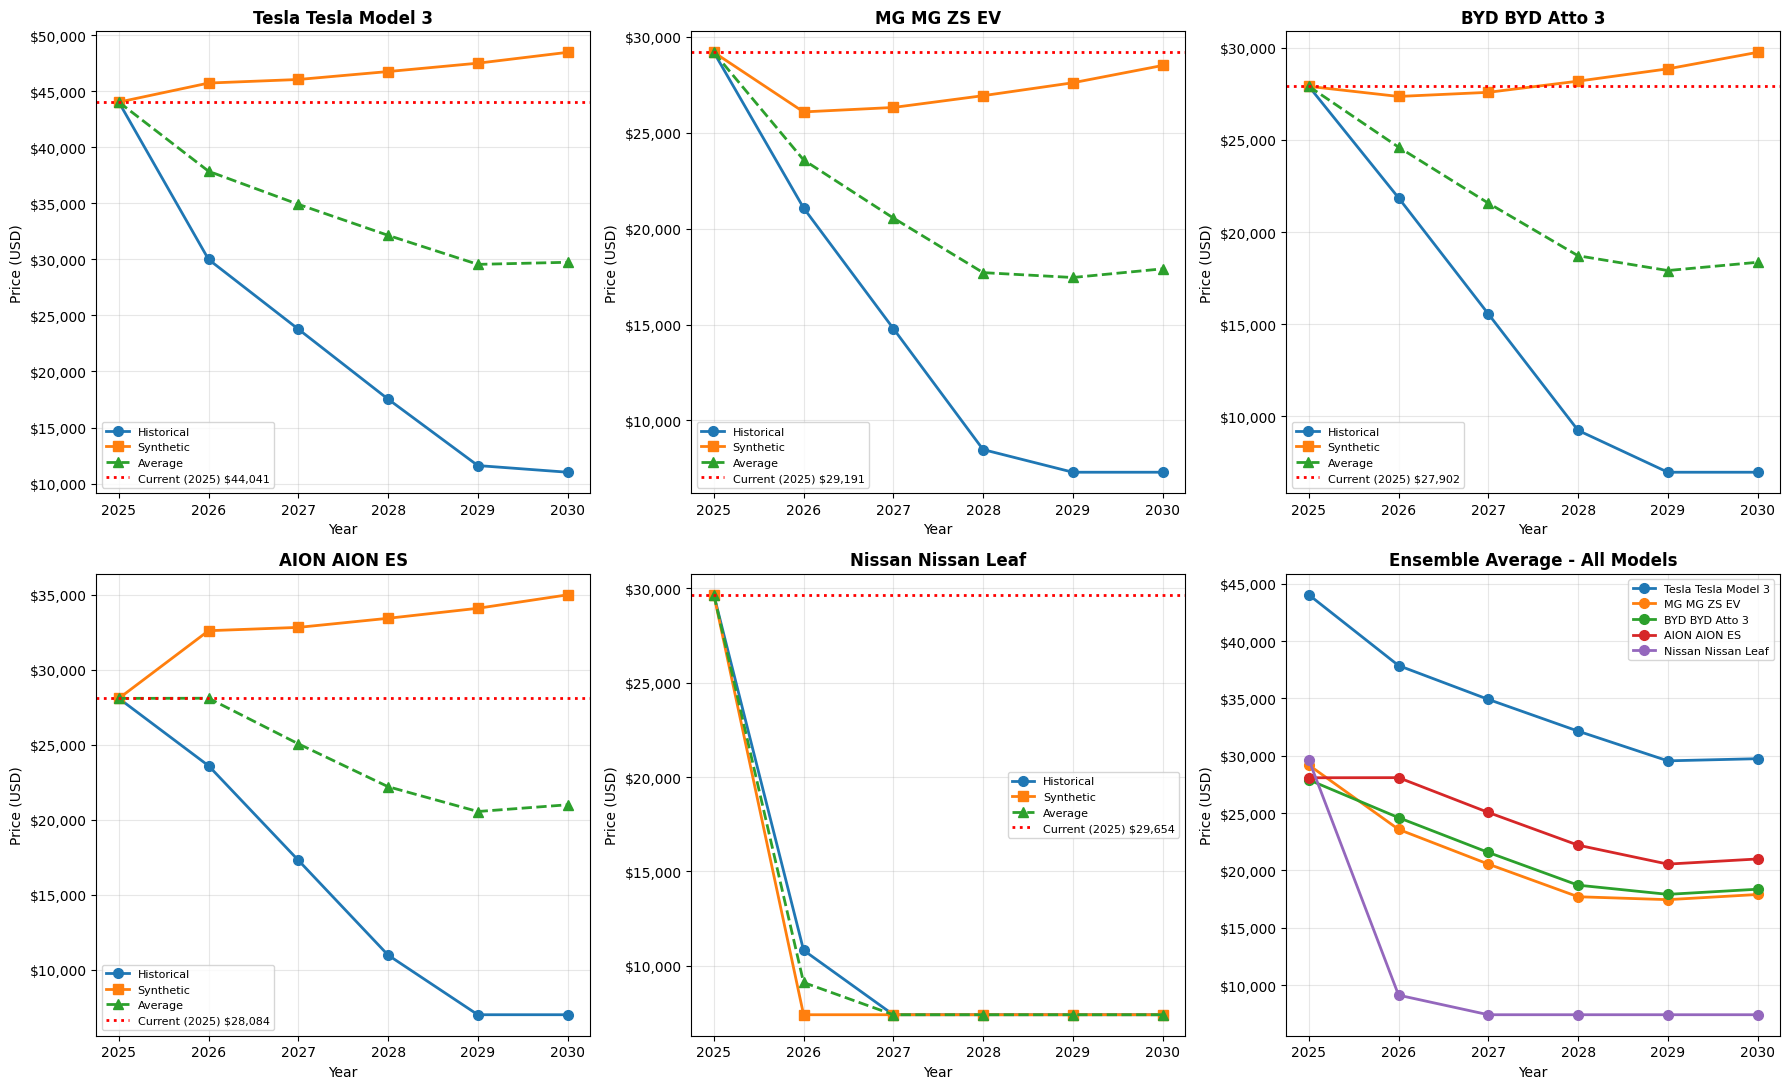

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
ax = axes.flatten()

for i, car in enumerate(pred_df['Car'].unique()):
    cdf = pred_df[pred_df['Car'] == car]
    current = cdf['Current'].iloc[0]
    ax[i].plot(cdf['Year'], cdf['Historical'], 'o-', lw=2, ms=7, label='Historical')
    ax[i].plot(cdf['Year'], cdf['Synthetic'], 's-', lw=2, ms=7, label='Synthetic')
    ax[i].plot(cdf['Year'], cdf['Average'], '^--', lw=2, ms=7, label='Average')
    ax[i].axhline(y=current, color='red', ls=':', lw=2, label=f'Current (2025) ${current:,.0f}')
    ax[i].set_title(car, fontsize=12, fontweight='bold')
    ax[i].set_xlabel('Year'); ax[i].set_ylabel('Price (USD)')
    ax[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax[i].legend(fontsize=8); ax[i].grid(alpha=0.3)

# Last subplot: Ensemble average comparison
for car in pred_df['Car'].unique():
    cdf = pred_df[pred_df['Car'] == car]
    ax[5].plot(cdf['Year'], cdf['Average'], 'o-', lw=2, ms=7, label=car)
ax[5].set_title('Ensemble Average - All Models', fontsize=12, fontweight='bold')
ax[5].set_xlabel('Year'); ax[5].set_ylabel('Price (USD)')
ax[5].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax[5].legend(fontsize=8); ax[5].grid(alpha=0.3)

plt.tight_layout(); plt.show()

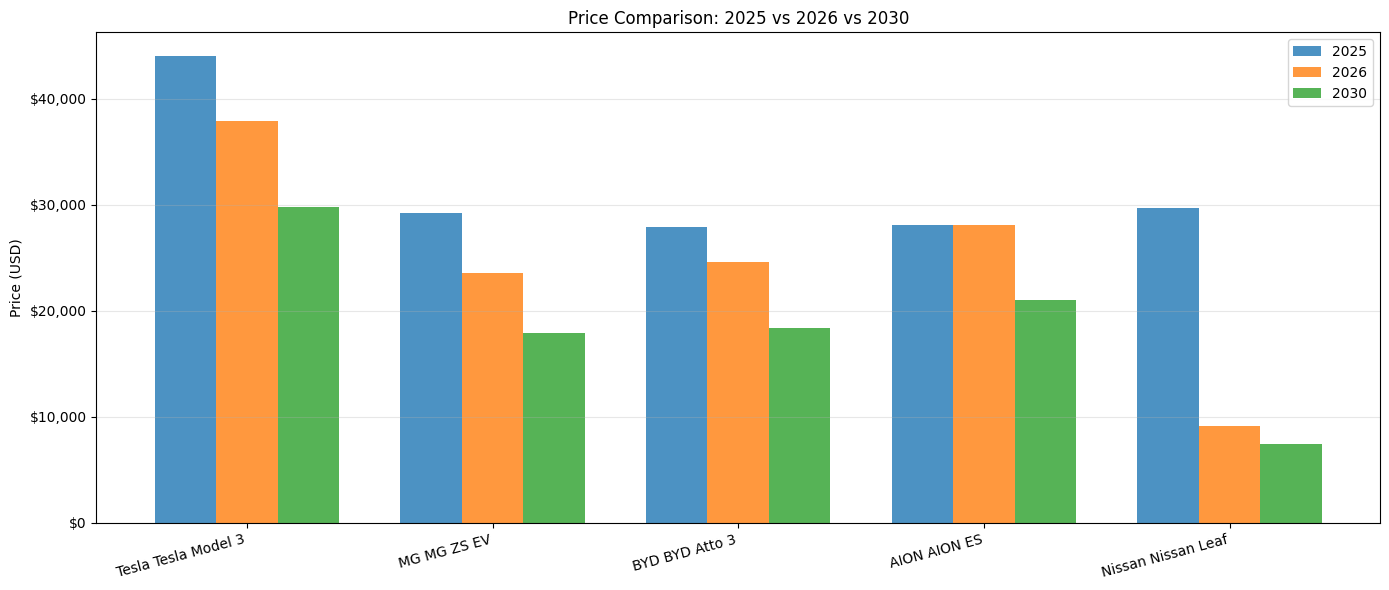

In [18]:
# Depreciation bar chart
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(analysis_df))
w = 0.25
ax.bar(x - w, analysis_df['2025 Price'], w, label='2025', alpha=0.8)
ax.bar(x, analysis_df['2026 Price'], w, label='2026', alpha=0.8)
ax.bar(x + w, analysis_df['2030 Price'], w, label='2030', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(analysis_df['Car'], rotation=15, ha='right')
ax.set_ylabel('Price (USD)'); ax.set_title('Price Comparison: 2025 vs 2026 vs 2030')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

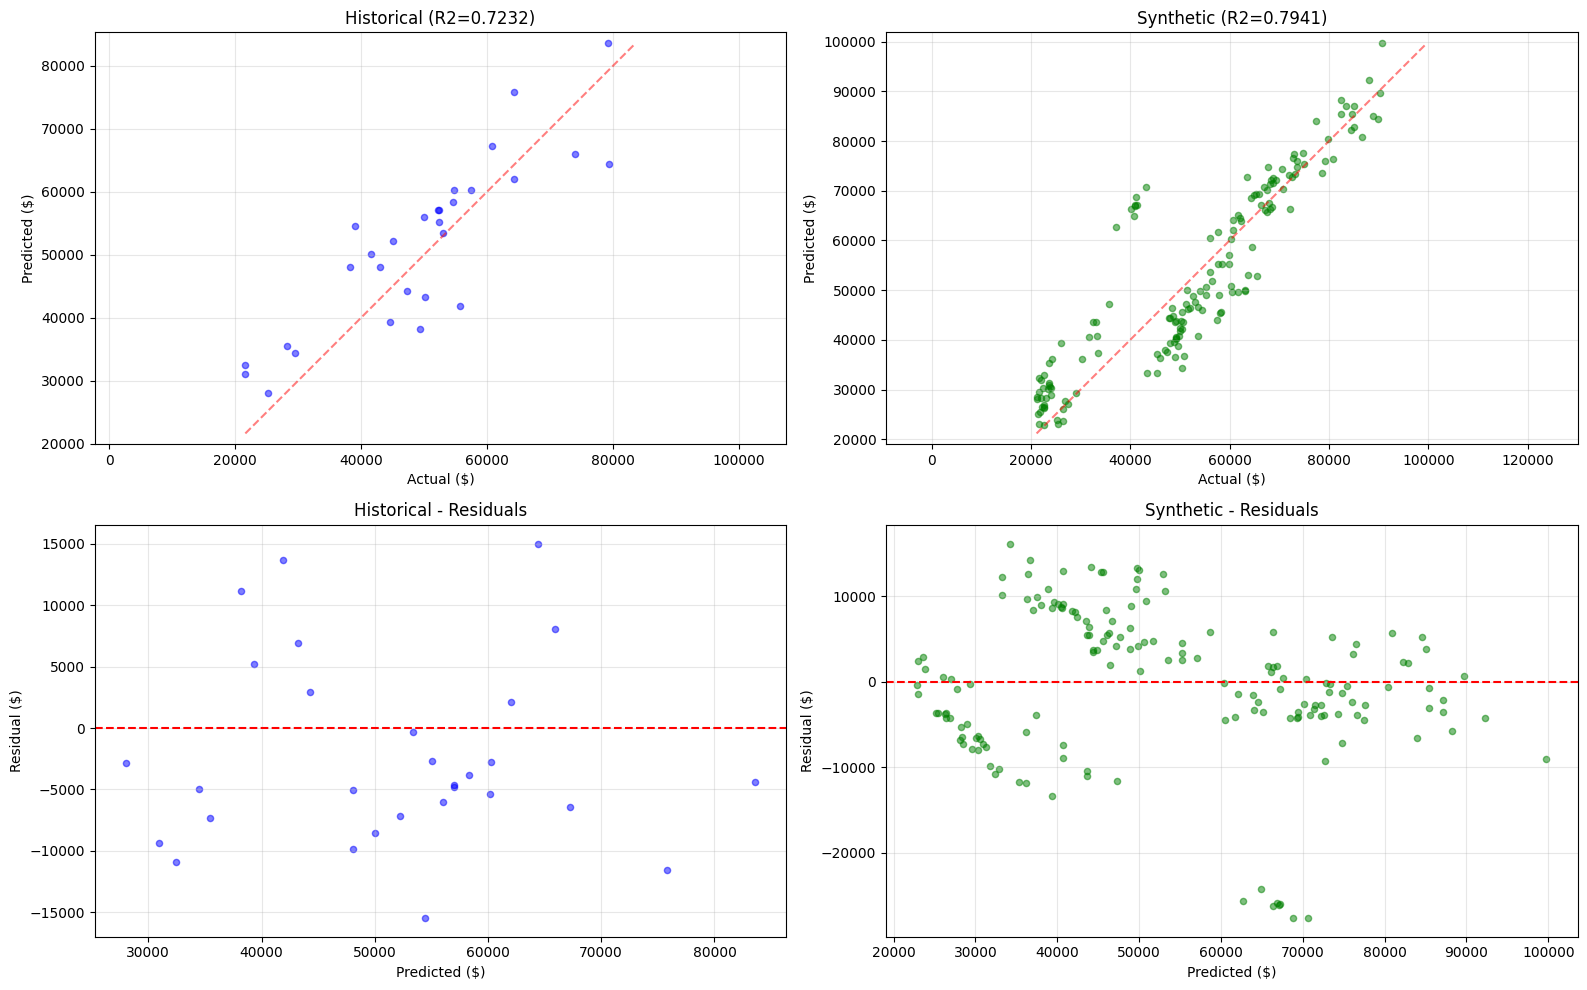

In [19]:
# Actual vs Predicted scatter (test set) + Residuals
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2, 2, figsize=(16, 10))

def act_vs_pred(model, test, ax, name, color):
    p = model.predict(test)
    ax.scatter(test['y'].values, p['yhat'].values, alpha=0.5, s=20, c=color)
    lims = [min(test['y'].min(), p['yhat'].min()), max(test['y'].max(), p['yhat'].max())]
    ax.plot(lims, lims, 'r--', alpha=0.5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual ($)'); ax.set_ylabel('Predicted ($)')
    r2 = r2_score(test['y'].values, p['yhat'].values)
    ax.set_title(f'{name} (R2={r2:.4f})'); ax.grid(alpha=0.3); ax.axis('equal')

act_vs_pred(m1, test1, ax1, 'Historical', 'blue')
act_vs_pred(m2, test2, ax2, 'Synthetic', 'green')

p1 = m1.predict(test1); r1 = test1['y'].values - p1['yhat'].values
ax3.scatter(p1['yhat'], r1, alpha=0.5, s=20, c='blue')
ax3.axhline(y=0, color='r', ls='--'); ax3.set_xlabel('Predicted ($)')
ax3.set_ylabel('Residual ($)'); ax3.set_title('Historical - Residuals'); ax3.grid(alpha=0.3)

p2 = m2.predict(test2); r2 = test2['y'].values - p2['yhat'].values
ax4.scatter(p2['yhat'], r2, alpha=0.5, s=20, c='green')
ax4.axhline(y=0, color='r', ls='--'); ax4.set_xlabel('Predicted ($)')
ax4.set_ylabel('Residual ($)'); ax4.set_title('Synthetic - Residuals'); ax4.grid(alpha=0.3)

plt.tight_layout(); plt.show()

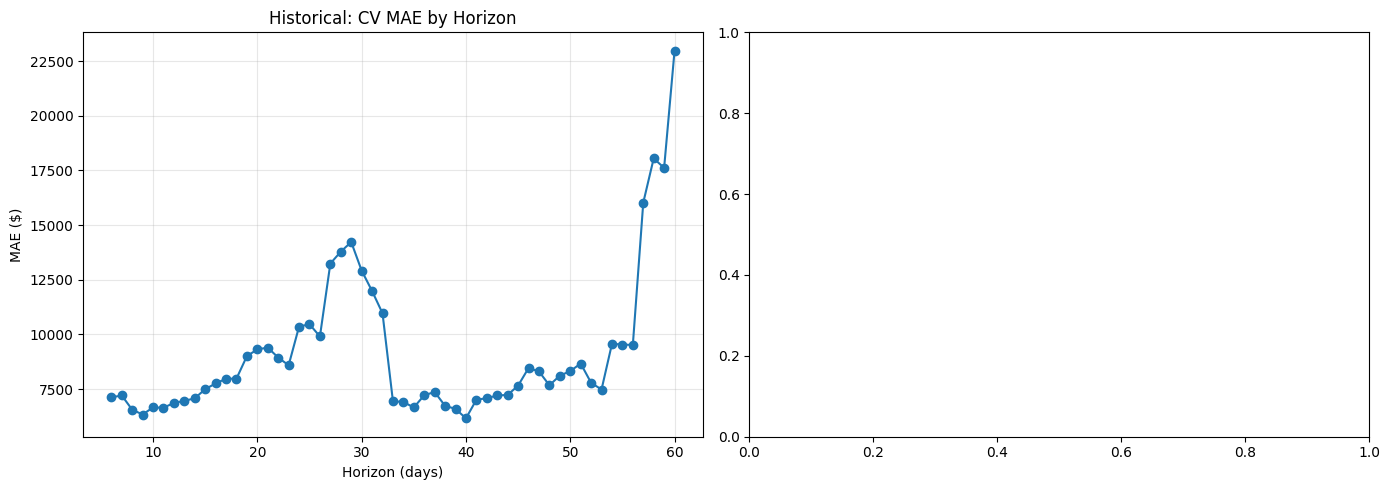

In [20]:
# CV performance plot
if pm1 is not None or pm2 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    if pm1 is not None:
        h1 = pm1['horizon'].dt.days.astype(int)
        axes[0].plot(h1, pm1['mae'], 'o-', label='Historical MAE')
        axes[0].set_xlabel('Horizon (days)'); axes[0].set_ylabel('MAE ($)')
        axes[0].set_title('Historical: CV MAE by Horizon'); axes[0].grid(alpha=0.3)
    if pm2 is not None:
        h2 = pm2['horizon'].dt.days.astype(int)
        axes[1].plot(h2, pm2['mape']*100, 's-', color='orange', label='Synthetic MAPE')
        axes[1].set_xlabel('Horizon (days)'); axes[1].set_ylabel('MAPE (%)')
        axes[1].set_title('Synthetic: CV MAPE by Horizon'); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 9. Final Report

In [21]:
print("="*70)
print("FINAL REPORT: EV PRICE PREDICTION - CAMBODIA MARKET")
print("="*70)

print("\n1. MODEL PERFORMANCE (TEST SET)")
for name, met in [('Historical', met1), ('Synthetic', met2)]:
    print(f"   {name}: MAE=${met['MAE']:,.0f}, MSE=${met['MSE']:,.0f}, RMSE=${met['RMSE']:,.0f}, MAPE={met['MAPE']:.2f}%, R2={met['R2']:.4f}")

print("\n2. CROSS-VALIDATION")
if pm1 is not None:
    print(f"   Historical: MAE=${pm1['mae'].mean():,.0f}, MAPE={pm1['mape'].mean()*100:.2f}%")
if pm2 is not None:
    print(f"   Synthetic: MAE=${pm2['mae'].mean():,.0f}, MAPE={pm2['mape'].mean()*100:.2f}%")

print("\n3. FIVE-YEAR PREDICTIONS (TOP 5 MODELS)")
display(pred_df.pivot_table(index='Car', columns='Year', values='Average', aggfunc='first').round(0))

print("\n4. DEPRECIATION ANALYSIS")
display(analysis_df)

print("\n5. MODEL CONSENSUS METRICS")
display(error_df)

print("\n6. KEY INSIGHTS")
for _, row in analysis_df.iterrows():
    trend = 'APPRECIATING' if row['5yr Change %'] > 0 else 'DEPRECIATING'
    print(f"   {row['Car']}: {trend} at {abs(row['Annual CAGR %']):.1f}%/yr (CAGR), {abs(row['5yr Change %']):.0f}% over 5 years")

print("\n7. RECOMMENDATIONS")
print("   - Use ensemble average for most stable predictions")
print("   - Historical model better for short-term (higher R2 stability)")
print("   - Synthetic model captures longer-term trends better")

FINAL REPORT: EV PRICE PREDICTION - CAMBODIA MARKET

1. MODEL PERFORMANCE (TEST SET)
   Historical: MAE=$6,882, MSE=$62,248,120, RMSE=$7,890, MAPE=16.05%, R2=0.7232
   Synthetic: MAE=$6,672, MSE=$77,507,086, RMSE=$8,804, MAPE=15.94%, R2=0.7941

2. CROSS-VALIDATION
   Historical: MAE=$9,177, MAPE=21.31%

3. FIVE-YEAR PREDICTIONS (TOP 5 MODELS)


Year,2025,2026,2027,2028,2029,2030
Car,,,,,,
AION AION ES,28084.0,28094.0,25058.0,22204.0,20552.0,21000.0
BYD BYD Atto 3,27902.0,24604.0,21569.0,18715.0,17914.0,18362.0
MG MG ZS EV,29191.0,23580.0,20552.0,17705.0,17451.0,17902.0
Nissan Nissan Leaf,29654.0,9121.0,7414.0,7414.0,7414.0,7414.0
Tesla Tesla Model 3,44041.0,37870.0,34919.0,32151.0,29560.0,29747.0



4. DEPRECIATION ANALYSIS


,Car,2025 Price,2026 Price,2030 Price,5yr Change %,Annual CAGR %
0,Tesla Tesla Model 3,44041,37870,29747,-32.5,-7.55
1,MG MG ZS EV,29191,23580,17902,-38.7,-9.32
2,BYD BYD Atto 3,27902,24604,18362,-34.2,-8.03
3,AION AION ES,28084,28094,21000,-25.2,-5.65
4,Nissan Nissan Leaf,29654,9121,7414,-75.0,-24.21



5. MODEL CONSENSUS METRICS


,Car,MAE ($),MSE ($),RMSE ($),Avg Disagreement %
0,Tesla Tesla Model 3,23440,715428510,26747,49.7
1,MG MG ZS EV,12750,226750820,15058,46.6
2,BYD BYD Atto 3,13518,255090940,15972,47.2
3,AION AION ES,16990,389686587,19740,50.2
4,Nissan Nissan Leaf,569,1943124,1394,5.3



6. KEY INSIGHTS
   Tesla Tesla Model 3: DEPRECIATING at 7.5%/yr (CAGR), 32% over 5 years
   MG MG ZS EV: DEPRECIATING at 9.3%/yr (CAGR), 39% over 5 years
   BYD BYD Atto 3: DEPRECIATING at 8.0%/yr (CAGR), 34% over 5 years
   AION AION ES: DEPRECIATING at 5.7%/yr (CAGR), 25% over 5 years
   Nissan Nissan Leaf: DEPRECIATING at 24.2%/yr (CAGR), 75% over 5 years

7. RECOMMENDATIONS
   - Use ensemble average for most stable predictions
   - Historical model better for short-term (higher R2 stability)
   - Synthetic model captures longer-term trends better
